In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from src.evaluation.metrics import (
    # compute_whole_body_suv_mae,
    # compute_brain_outlier_score,
    # compute_organ_bias,
    # compute_tac_bias,
    compute_whole_body_mu_mae,
)

In [2]:
filepath= "data/sub-000/ct-label/organ_seg.nii.gz"
img_organ_seg = nib.load(filepath)
data_organ_seg = img_organ_seg.get_fdata()

In [3]:
filepath_pet= "data/sub-000/features/nacpet.nii.gz"
img_pet = nib.load(filepath_pet)
data_pet = img_pet.get_fdata()

In [4]:
filepath_mri = "data/sub-000/features/mri_combined_in_phase.nii.gz"
img_mri = nib.load(filepath_mri)
data_mri = img_mri.get_fdata()

In [5]:
filepath_topo = "data/sub-000/features/topogram.nii.gz"
img_topo = nib.load(filepath_topo)
data_topo = img_topo.get_fdata()

In [6]:
red_topo = np.squeeze(data_topo, axis=1)
squeezed_topo= data_topo.squeeze(axis=1)
red_topo.shape

(512, 531)

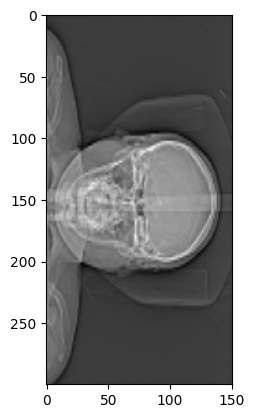

In [7]:
plt.imshow(squeezed_topo[100:400, 380:], cmap="gray")
# plt.imshow(squeezed_topo[:, :], cmap="gray")
# plt.imshow(data[250,:,:]==90, cmap="gray")
# plt.show()

In [8]:
data_pet.shape
# slice_index=data_pet.shape[2]//2

(512, 512, 531)

In [9]:
data_organ_seg.shape

(512, 512, 531)

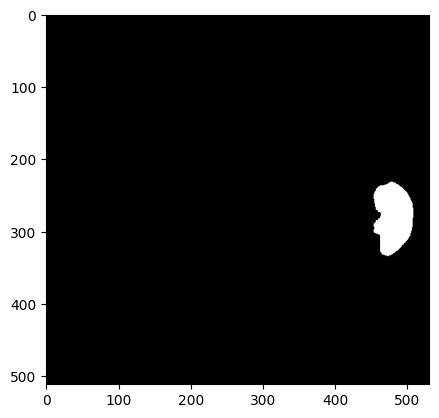

In [10]:
# plt.imshow(data_organ_seg[:,:,500]==90, cmap="gray")
plt.imshow(data_organ_seg[270,:,:]==90, cmap="gray")
# brain_data = data_pet[180:400, 180:400,400:]

In [11]:
# plt.imshow(data_organ_seg[:,300,:]==90, cmap="gray")

In [12]:
data_pet.shape

(512, 512, 531)

In [13]:
# # plt.imshow(data_pet[250,:,:]==90, cmap="gray")
# plt.imshow(data_pet[:,:,470], cmap="gray")

In [14]:
# pet_brain_data = data_pet[180:400, 180:400,400:531]
# mri_brain_data = data_mri[180:400, 180:400,400:531]
# pet_brain_data.shape

In [15]:
# mri_brain_data.shape

In [16]:
# plt.imshow(pet_brain_data[:,:,100], cmap="gray")

In [17]:
# plt.imshow(data_pet[:,:,500], cmap="gray")

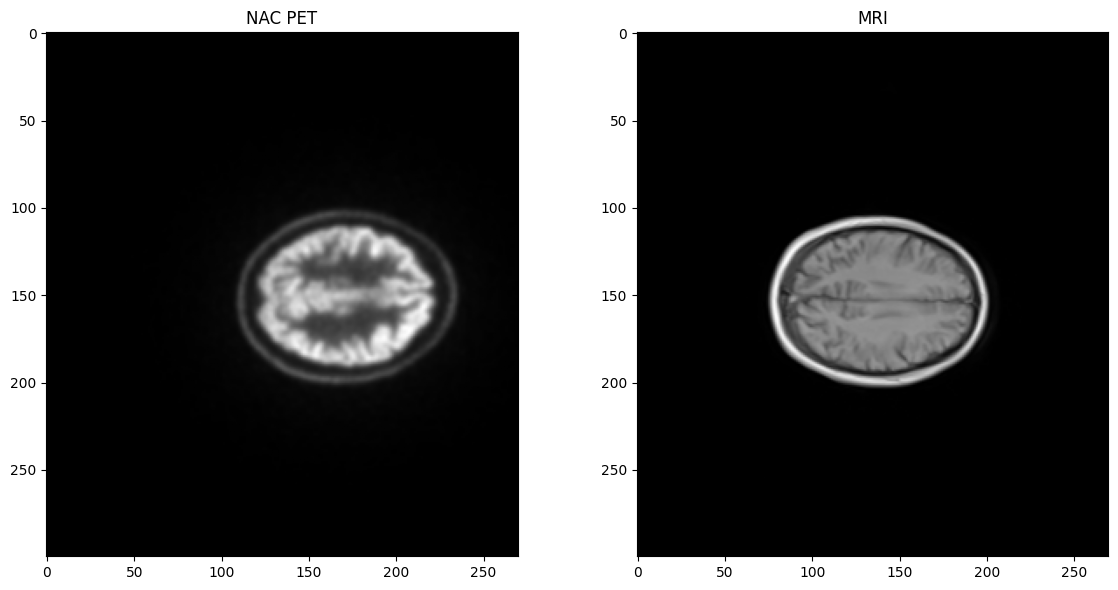

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(data_pet[100:400,110:380,490], cmap="gray")
axes[0].set_title("NAC PET")
axes[1].imshow(data_mri[100:400,110:380,500], cmap="gray")
axes[1].set_title("MRI")
plt.tight_layout()
plt.show()

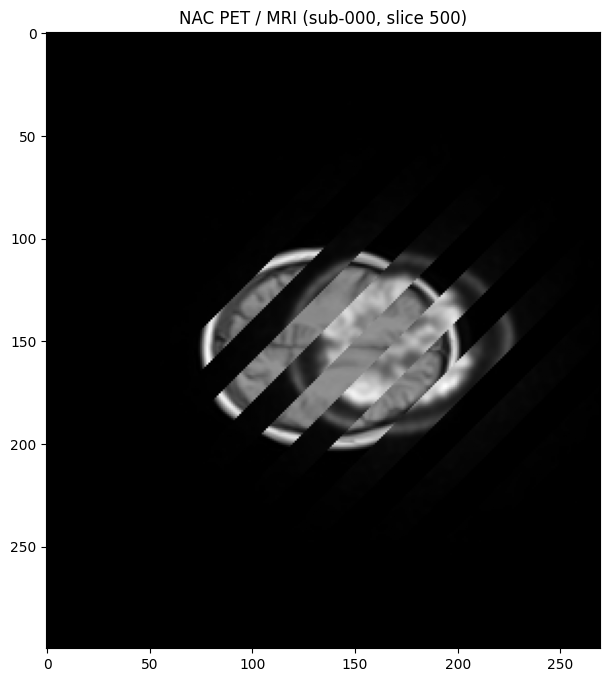

In [ ]:
def diagonal_overlay(img_a, img_b, tile_size=20):
    # min-max normalize each image independently so tile brightness is comparable
    # (PET and MRI intensities live on totally different scales)
    a = (img_a - img_a.min()) / (img_a.max() - img_a.min() + 1e-8)
    b = (img_b - img_b.min()) / (img_b.max() - img_b.min() + 1e-8)
    tile_mask = (np.indices(a.shape).sum(axis=0) // tile_size) % 2 == 0
    return np.where(tile_mask, a, b)

slice_no = 500
pet_slice = data_pet[100:400, 110:380, slice_no]
mri_slice = data_mri[100:400, 110:380, slice_no]
board = diagonal_overlay(pet_slice, mri_slice, tile_size=20)

plt.figure(figsize=(8, 8))
plt.imshow(board, cmap="gray")
plt.title("NAC PET / MRI (sub-000, slice 500)")
# plt.axis("off")
plt.show()

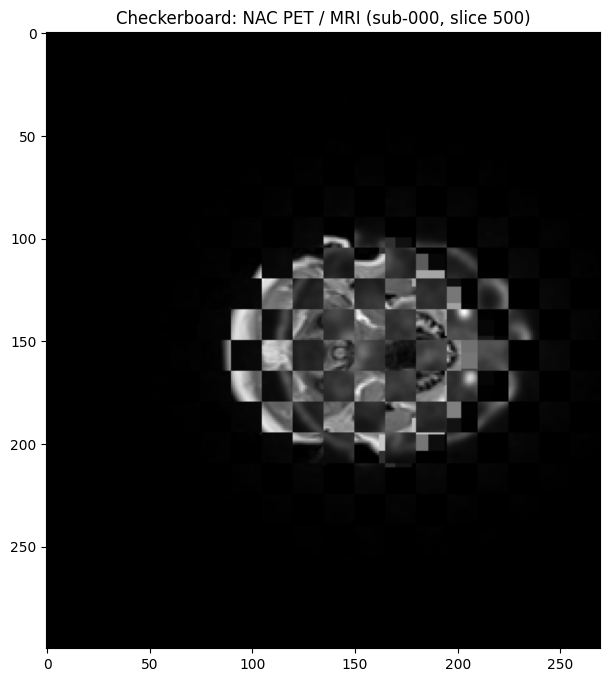

In [ ]:
def checkerboard_overlay(img_a, img_b, tile_size=20):
    # min-max normalize each image independently so tile brightness is comparable
    # (PET and MRI intensities live on totally different scales)
    a = (img_a - img_a.min()) / (img_a.max() - img_a.min() + 1e-8)
    b = (img_b - img_b.min()) / (img_b.max() - img_b.min() + 1e-8)
    row_tile, col_tile = np.indices(a.shape) // tile_size
    tile_mask = (row_tile + col_tile) % 2 == 0
    return np.where(tile_mask, a, b)

slice_no = 500
pet_slice = data_pet[100:400, 110:380, slice_no]
mri_slice = data_mri[100:400, 110:380, slice_no]
board = checkerboard_overlay(pet_slice, mri_slice, tile_size=15)

plt.figure(figsize=(8, 8))
plt.imshow(board, cmap="gray")
plt.title("Checkerboard: NAC PET / MRI (sub-000, slice 500)")
# plt.axis("off")
plt.show()

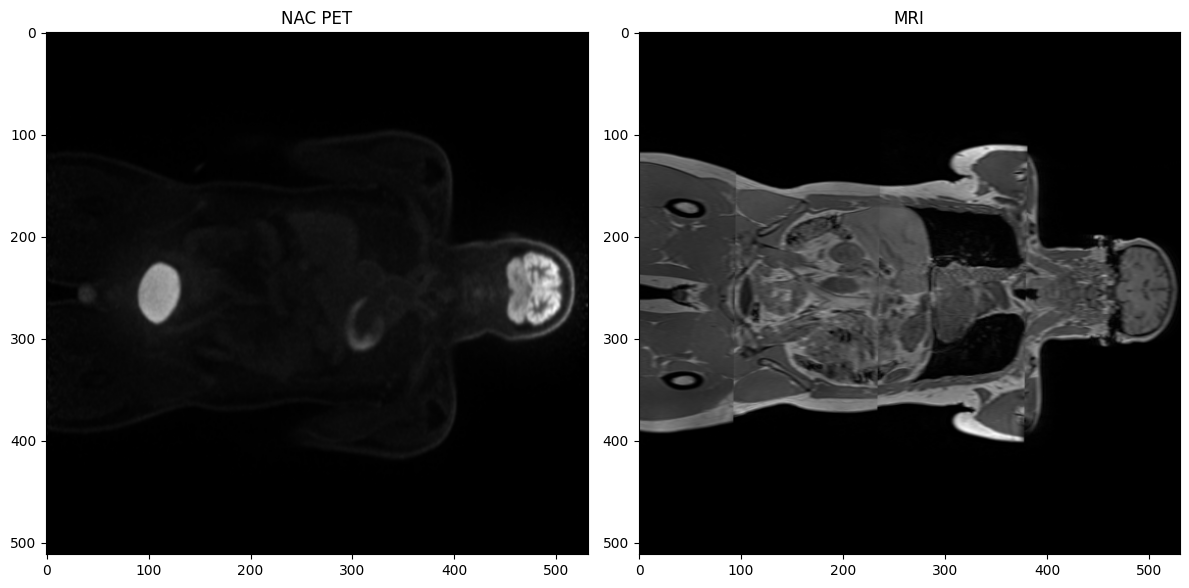

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(data_pet[:,250,:], cmap="gray")
axes[0].set_title("NAC PET")
axes[1].imshow(data_mri[:,250,:], cmap="gray")
axes[1].set_title("MRI")
plt.tight_layout()
plt.show()

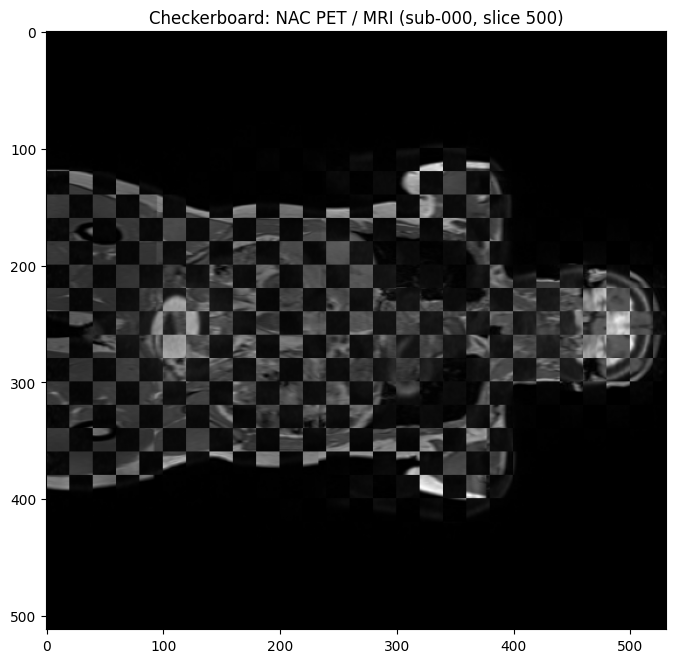

In [22]:
board = checkerboard_overlay(data_pet[:,250,:], data_mri[:,250,:], tile_size=20)

plt.figure(figsize=(8, 8))
plt.imshow(board, cmap="gray")
plt.title("Checkerboard: NAC PET / MRI (sub-000, slice 500)")
# plt.axis("off")
plt.show()